## PCA vs Kernel PCA on Synthetic Data

This notebook compares PCA and Kernel PCA on four synthetic datasets with increasing nonlinearity. The goal is to understand when KPCA provides a genuine advantage over standard PCA, and why that advantage disappears on high-dimensional face images.

We start with an interactive demonstration of how PCA selects its projection direction, then apply both methods to progressively harder datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Helper Functions


In [2]:
def center_data(X):
    """Subtract the mean from each feature."""
    return X - X.mean(axis=0)

def cov_matrix(X):
    """Compute covariance matrix."""
    X = np.asarray(X, dtype=float)
    Xc = X - X.mean(axis=0)
    return (Xc.T @ Xc) / (len(X) - 1)

def pca_project(X, n_components=2):
    """PCA: eigendecomposition of covariance matrix, project to top components."""
    Xc = center_data(X)
    S = cov_matrix(X)
    eigvals, eigvecs = np.linalg.eigh(S)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    W = eigvecs[:, :n_components]
    Z = Xc @ W
    ratios = eigvals / eigvals.sum()
    return Z, eigvecs, eigvals, ratios

def poly_kernel(X, Y, degree=3, coef0=1.0):
    """Polynomial kernel: K(x,y) = (x^T y + c)^d."""
    return (np.asarray(X) @ np.asarray(Y).T + coef0) ** degree

def gaussian_kernel(X, Y, sigma=1.0):
    """Gaussian kernel: K(x,y) = exp(-||x-y||^2 / 2*sigma^2)."""
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    X_sq = np.sum(X**2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y**2, axis=1).reshape(1, -1)
    return np.exp(-(X_sq + Y_sq - 2 * X @ Y.T) / (2 * sigma**2))

def center_kernel(K):
    """Center kernel matrix in feature space."""
    n = K.shape[0]
    one_n = np.ones((n, n)) / n
    return K - one_n @ K - K @ one_n + one_n @ K @ one_n

def kpca_project(X, kernel_func, n_components=2, **kernel_params):
    """Kernel PCA: build kernel matrix, center, eigendecompose, project."""
    K = kernel_func(X, X, **kernel_params)
    Kc = center_kernel(K)
    eigvals, eigvecs = np.linalg.eigh(Kc)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # Normalize and project
    pos = eigvals > 1e-10
    alpha = eigvecs[:, :n_components] / np.sqrt(np.maximum(eigvals[:n_components], 1e-10))
    Z = Kc @ alpha
    ratios = eigvals[pos] / eigvals[pos].sum()
    return Z, eigvals, ratios


In [3]:
def plot_pca_vectors(X, eigvecs, eigvals, title="PCA"):
    """Plot data with principal component directions."""
    mu = X.mean(axis=0)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[:, 0], X[:, 1], s=30, alpha=0.6)
    
    data_range = max(X[:, 0].max() - X[:, 0].min(), X[:, 1].max() - X[:, 1].min())
    
    for i, (vec, val) in enumerate(zip(eigvecs.T[:2], eigvals[:2])):
        ratio = val / eigvals[0]
        scale = data_range * 0.35 * ratio
        color = ['red', 'blue'][i]
        end = mu + vec * scale
        ax.annotate('', xy=end, xytext=mu,
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(end[0] + data_range*0.03, end[1] + data_range*0.03,
                f"PC{i+1} ({val:.2f})", color=color, fontsize=10, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    return fig, ax

def plot_comparison(X, Z_pca, Z_kpca, pca_ratios, kpca_ratios, title="", colors=None):
    """Side-by-side: original data, PCA 1D projection, KPCA 1D projection."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    c = colors if colors is not None else 'steelblue'
    
    # Original data
    axes[0].scatter(X[:, 0], X[:, 1], c=c, s=30, alpha=0.7, edgecolors='white', linewidths=0.3)
    axes[0].set_title("Original Data", fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # PCA: plot as 1D strip (index vs PC1) when PC1 dominates, else 2D scatter
    if pca_ratios[0] > 0.9:
        # PC1 dominates: show 1D projection
        order = np.argsort(Z_pca[:, 0])
        axes[1].scatter(Z_pca[order, 0], np.zeros_like(Z_pca[:, 0]),
                        c=np.array(c)[order] if isinstance(c, np.ndarray) else c,
                        s=40, alpha=0.7, edgecolors='white', linewidths=0.3)
        axes[1].set_xlabel(f"PC1 ({pca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[1].set_yticks([])
        axes[1].set_ylim(-1, 1)
    else:
        axes[1].scatter(Z_pca[:, 0], Z_pca[:, 1], c=c, s=30, alpha=0.7,
                        edgecolors='white', linewidths=0.3)
        axes[1].set_xlabel(f"PC1 ({pca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[1].set_ylabel(f"PC2 ({pca_ratios[1]*100:.1f}%)", fontsize=11)
    axes[1].axhline(0, c='gray', lw=0.5); axes[1].axvline(0, c='gray', lw=0.5)
    axes[1].set_title("PCA Projection", fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    # KPCA
    if kpca_ratios[0] > 0.9:
        order = np.argsort(Z_kpca[:, 0])
        axes[2].scatter(Z_kpca[order, 0], np.zeros_like(Z_kpca[:, 0]),
                        c=np.array(c)[order] if isinstance(c, np.ndarray) else c,
                        s=40, alpha=0.7, edgecolors='white', linewidths=0.3)
        axes[2].set_xlabel(f"KPC1 ({kpca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[2].set_yticks([])
        axes[2].set_ylim(-1, 1)
    else:
        axes[2].scatter(Z_kpca[:, 0], Z_kpca[:, 1], c=c, s=30, alpha=0.7,
                        edgecolors='white', linewidths=0.3)
        axes[2].set_xlabel(f"KPC1 ({kpca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[2].set_ylabel(f"KPC2 ({kpca_ratios[1]*100:.1f}%)", fontsize=11)
    axes[2].axhline(0, c='gray', lw=0.5); axes[2].axvline(0, c='gray', lw=0.5)
    axes[2].set_title("Kernel PCA Projection", fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### Interactive PCA: Why This Direction?

Before comparing PCA and KPCA, let's build intuition for what PCA actually optimizes. The data below follows a linear relationship ($y \approx 0.5x + \text{noise}$), the same data we will analyze in Dataset 1.

Drag the slider to rotate the projection axis. The left panel shows original points (blue) and their projections onto the axis (orange). The right panels show the 1D projected distribution and the variance at each angle. PCA picks the angle that maximizes this variance.

In [4]:
import altair as alt
import pandas as pd

alt.data_transformers.disable_max_rows()

# Generate data
np.random.seed(0)
X_demo = np.random.uniform(0, 10, size=(30, 2))
X_demo[:, 1] = 0.5 * X_demo[:, 0] + np.random.uniform(-0.5, 0.5, 30)
X_c = X_demo - X_demo.mean(axis=0)
mu = X_demo.mean(axis=0)

# PCA solution
S = cov_matrix(X_demo)
eigvals, eigvecs = np.linalg.eigh(S)
idx_sort = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx_sort]; eigvecs = eigvecs[:, idx_sort]
pca_angle = int(np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0])) % 180)

# PCA projection (fixed reference)
w_pca = np.array([np.cos(np.radians(pca_angle)), np.sin(np.radians(pca_angle))])
pca_proj_vals = X_c @ w_pca

# Precompute for all angles
rows_data = []
rows_var = []
rows_line = []

for angle in range(0, 180):
    rad = np.radians(angle)
    w = np.array([np.cos(rad), np.sin(rad)])
    proj_vals = X_c @ w
    proj_pts = mu + np.outer(proj_vals, w)
    var = float(np.var(proj_vals))

    for j in range(len(X_demo)):
        rows_data.append({
            'angle': angle,
            'x_orig': float(X_demo[j, 0]), 'y_orig': float(X_demo[j, 1]),
            'x_proj': float(proj_pts[j, 0]), 'y_proj': float(proj_pts[j, 1]),
            'proj_val': float(proj_vals[j]),
            'pca_proj_val': float(pca_proj_vals[j]),
        })
    rows_var.append({'angle': angle, 'variance': var})
    for t in [-15, 15]:
        rows_line.append({
            'angle': angle,
            'x_line': float(mu[0] + t * w[0]),
            'y_line': float(mu[1] + t * w[1])
        })

# Duplicate 0 as 180
for r in [r.copy() for r in rows_data if r['angle'] == 0]:
    r['angle'] = 180; rows_data.append(r)
for r in [r.copy() for r in rows_var if r['angle'] == 0]:
    r['angle'] = 180; rows_var.append(r)
for r in [r.copy() for r in rows_line if r['angle'] == 0]:
    r['angle'] = 180; rows_line.append(r)

df_data = pd.DataFrame(rows_data)
df_var = pd.DataFrame(rows_var)
df_line = pd.DataFrame(rows_line)

# Slider
slider = alt.binding_range(min=0, max=180, step=1, name='Projection Angle (°): ')
sel = alt.selection_point(fields=['angle'], bind=slider, value=pca_angle)

# --- Left: data + projection ---
original = alt.Chart(df_data).transform_filter(sel).mark_circle(size=60, opacity=0.7).encode(
    x=alt.X('x_orig:Q', title='x\u2081', scale=alt.Scale(domain=[-2, 12])),
    y=alt.Y('y_orig:Q', title='x\u2082', scale=alt.Scale(domain=[-3, 7])),
    color=alt.value('steelblue')
)
projected = alt.Chart(df_data).transform_filter(sel).mark_circle(size=50, opacity=0.8).encode(
    x='x_proj:Q', y='y_proj:Q', color=alt.value('tomato')
)
drop = alt.Chart(df_data).transform_filter(sel).mark_rule(strokeWidth=0.8, opacity=0.3).encode(
    x='x_orig:Q', y='y_orig:Q', x2='x_proj:Q', y2='y_proj:Q', color=alt.value('gray')
)
proj_line = alt.Chart(df_line).transform_filter(sel).mark_line(
    strokeWidth=2.5, opacity=0.8, clip=True
).encode(x='x_line:Q', y='y_line:Q', color=alt.value('red'))

left = (original + projected + drop + proj_line).add_params(sel).properties(
    width=400, height=390, title='Drag the slider to rotate projection direction'
)

# --- Top right: 1D strip, same row, PCA=red, current=blue ---
strip_current = alt.Chart(df_data).transform_filter(sel).mark_circle(size=55, opacity=0.8).encode(
    x=alt.X('proj_val:Q', title='Projected value', scale=alt.Scale(domain=[-6, 6])),
    y=alt.value(50),
    color=alt.value('steelblue')
)
strip_pca = alt.Chart(df_data).transform_filter(sel).mark_circle(size=55, opacity=0.5).encode(
    x=alt.X('pca_proj_val:Q', scale=alt.Scale(domain=[-6, 6])),
    y=alt.value(50),
    color=alt.value('red')
)
# Legend labels
label_current = alt.Chart(pd.DataFrame({'t': ['● Current angle']})).mark_text(
    fontSize=10, color='steelblue', align='left'
).encode(x=alt.value(15), y=alt.value(15), text='t:N')
label_pca = alt.Chart(pd.DataFrame({'t': [f'● PCA ({pca_angle}°)']})).mark_text(
    fontSize=10, color='red', align='left'
).encode(x=alt.value(140), y=alt.value(15), text='t:N')
# Variance
var_text = alt.Chart(df_var).transform_filter(sel).mark_text(
    fontSize=12, fontWeight='bold', color='red'
).encode(x=alt.value(360), y=alt.value(15), text=alt.Text('variance:Q', format='.3f'))
var_prefix = alt.Chart(pd.DataFrame({'t': ['Var: ']})).mark_text(
    fontSize=12, color='black'
).encode(x=alt.value(330), y=alt.value(15), text='t:N')

middle = (strip_pca + strip_current + label_current + label_pca + var_text + var_prefix).properties(
    width=400, height=80, title='Projected points: current angle vs PCA'
)

# --- Bottom right: variance curve ---
var_curve = alt.Chart(df_var).mark_line(color='steelblue', strokeWidth=2).encode(
    x=alt.X('angle:Q', title='Angle (°)', scale=alt.Scale(domain=[0, 180])),
    y=alt.Y('variance:Q', title='Variance')
)
var_marker = alt.Chart(df_var).transform_filter(sel).mark_circle(size=120, color='red').encode(
    x='angle:Q', y='variance:Q'
)
pca_ref = alt.Chart(pd.DataFrame({'angle': [pca_angle]})).mark_rule(
    color='red', strokeDash=[5, 3], strokeWidth=1.5
).encode(x='angle:Q')
pca_label = alt.Chart(pd.DataFrame({
    'angle': [pca_angle], 'y': [float(max(r['variance'] for r in rows_var)) * 0.95],
    'label': [f'PCA ({pca_angle}°)']
})).mark_text(color='red', fontSize=11, align='left', dx=5).encode(
    x='angle:Q', y='y:Q', text='label:N'
)

right = (var_curve + var_marker + pca_ref + pca_label).properties(
    width=400, height=310, title='Projected variance at each angle'
)

left | (middle & right)


alt.HConcatChart(...)

### Dataset 1: Linear Relationship

The same linear data from the interactive demo above. Since the structure is linear, PCA's variance-maximizing direction should capture it well. We compare PCA (eigenvectors of the covariance matrix) with KPCA (polynomial kernel, degree 3).

Data shape: (30, 2)

Covariance matrix:
[[8.2   4.026]
 [4.026 2.068]]

Eigenvalues: [10.1946  0.0736]
Explained variance: 99.3%, 0.7%
PC1 direction: [-0.896, -0.444]

KPCA top eigenvalues: [5.13979749e+06 2.17135700e+04 3.88445000e+03 4.10400000e+01
 1.16700000e+01]
KPCA explained variance: 99.5%, 0.4%


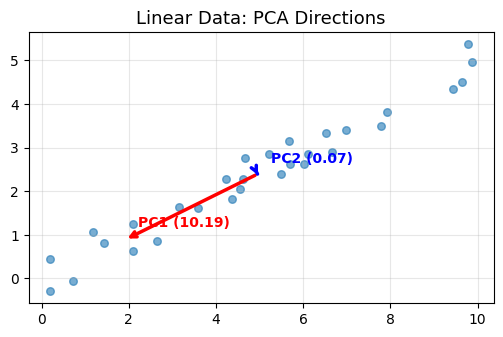

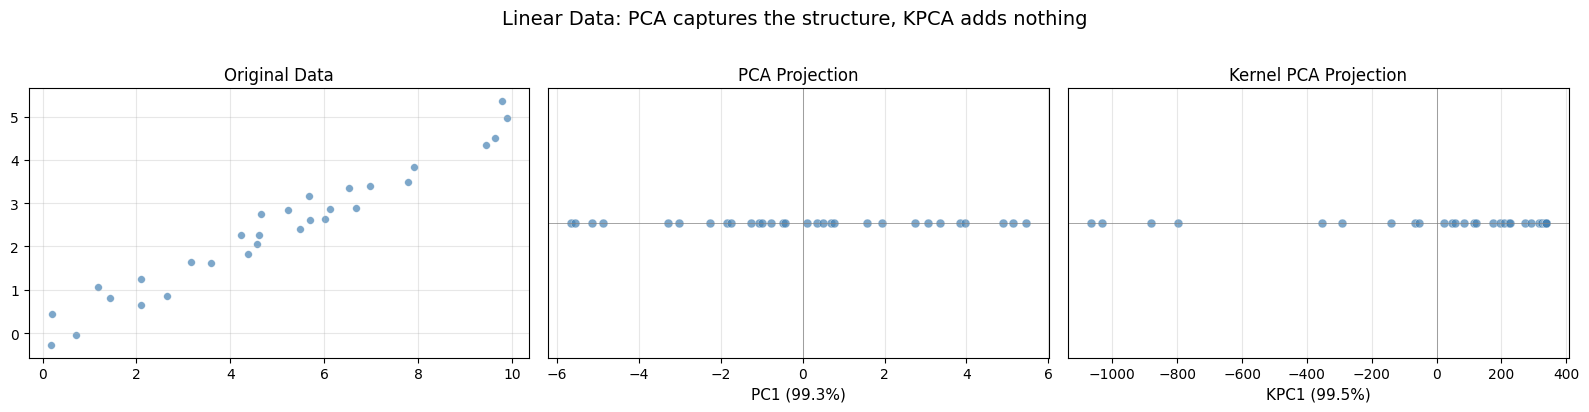

In [5]:
np.random.seed(0)
data_1 = np.random.uniform(0, 10, size=(30, 2))
data_1[:, 1] = 0.5 * data_1[:, 0] + np.random.uniform(-0.5, 0.5, 30)

print(f"Data shape: {data_1.shape}")

# PCA
S = cov_matrix(data_1)
print(f"\nCovariance matrix:\n{S.round(3)}")

Z_pca, eigvecs, eigvals, pca_ratios = pca_project(data_1)
print(f"\nEigenvalues: {eigvals.round(4)}")
print(f"Explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")
print(f"PC1 direction: [{eigvecs[0,0]:.3f}, {eigvecs[1,0]:.3f}]")

# KPCA
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(data_1, poly_kernel, degree=3, coef0=1.0)
print(f"\nKPCA top eigenvalues: {kpca_eigvals[:5].round(2)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

plot_pca_vectors(data_1, eigvecs, eigvals, "Linear Data: PCA Directions")
plt.show()

plot_comparison(data_1, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Linear Data: PCA captures the structure, KPCA adds nothing")


### Dataset 2: Nonlinear Decision Boundary

Points are sampled uniformly, then labeled by which side of the parabola $y = x^2$ they fall on. The decision boundary is inherently nonlinear — no straight line can separate the two classes. PCA projects onto a linear direction, mixing the classes. KPCA with a polynomial kernel can capture the $x^2$ structure and pull the classes apart.

Data shape: (150, 2)
Class 0 (below y=x²): 52, Class 1 (above y=x²): 98

Covariance matrix:
[[ 5.628  0.493]
 [ 0.493 33.968]]

PCA eigenvalues: [33.9769  5.619 ]
PCA explained variance: 85.8%, 14.2%

KPCA top eigenvalues: [1.41856826e+06 1.73239690e+05 3.36865000e+03 9.22730000e+02
 5.52230000e+02]
KPCA explained variance: 88.8%, 10.9%


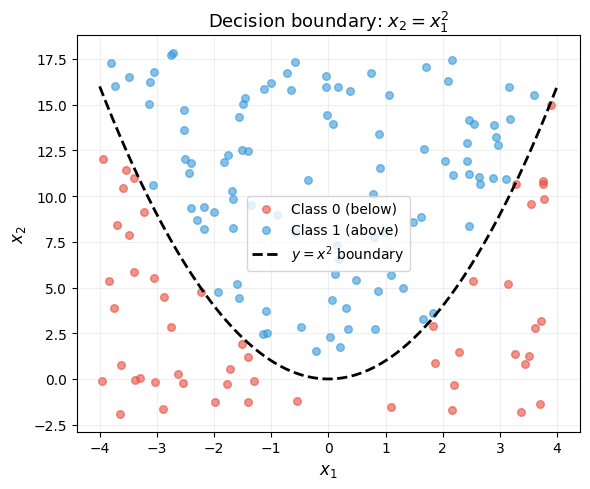

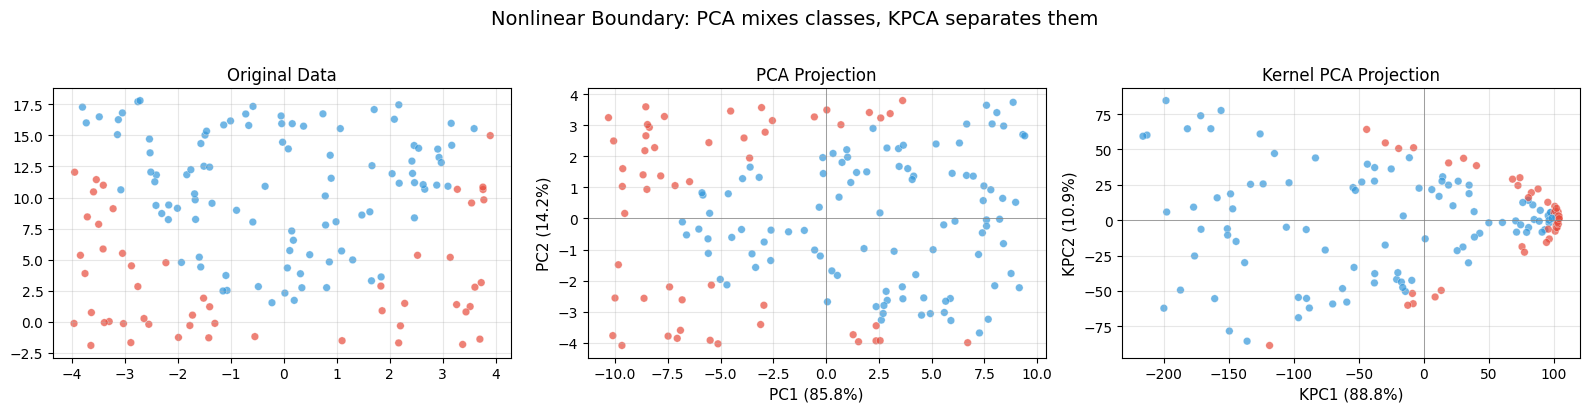

In [6]:
np.random.seed(42)
# Sample points uniformly in a box
n_points = 150
data_2 = np.column_stack([
    np.random.uniform(-4, 4, n_points),
    np.random.uniform(-2, 18, n_points)
])

# Label by parabola boundary: y > x^2 -> class 1, else class 0
labels_2 = (data_2[:, 1] > data_2[:, 0]**2).astype(int)
quad_colors = np.array(['#e74c3c', '#3498db'])[labels_2]

print(f"Data shape: {data_2.shape}")
print(f"Class 0 (below y=x²): {np.sum(labels_2==0)}, Class 1 (above y=x²): {np.sum(labels_2==1)}")

# PCA
S = cov_matrix(data_2)
print(f"\nCovariance matrix:\n{S.round(3)}")

Z_pca, eigvecs, eigvals, pca_ratios = pca_project(data_2)
print(f"\nPCA eigenvalues: {eigvals.round(4)}")
print(f"PCA explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")

# KPCA with polynomial kernel
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(data_2, poly_kernel, degree=2, coef0=1.0)
print(f"\nKPCA top eigenvalues: {kpca_eigvals[:5].round(2)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

# Plot the decision boundary explicitly
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(data_2[labels_2==0, 0], data_2[labels_2==0, 1], c='#e74c3c', s=30, alpha=0.6, label='Class 0 (below)')
ax.scatter(data_2[labels_2==1, 0], data_2[labels_2==1, 1], c='#3498db', s=30, alpha=0.6, label='Class 1 (above)')
x_curve = np.linspace(-4, 4, 200)
ax.plot(x_curve, x_curve**2, 'k--', lw=2, label='$y = x^2$ boundary')
ax.set_xlabel('$x_1$', fontsize=12); ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Decision boundary: $x_2 = x_1^2$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# PCA vs KPCA projections
plot_comparison(data_2, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Nonlinear Boundary: PCA mixes classes, KPCA separates them",
                colors=quad_colors)


The first two datasets are single-class — we only care about capturing variance. The next two datasets have **multiple classes** with nonlinear boundaries. Here the question changes: can the projection **separate** different classes? We switch to a Gaussian kernel, which is better suited for capturing local cluster structure.

### Dataset 3: Concentric Rings

Three classes arranged as concentric rings. No linear projection can separate them — any direction mixes the classes. KPCA with a Gaussian kernel ($\sigma = 2.0$) maps the data into a feature space where the rings become linearly separable.

Data shape: (115, 2)
Classes: 35 inner, 45 middle, 35 outer

PCA eigenvalues: [10.0604  7.6095]
PCA explained variance: 56.9%, 43.1%

KPCA sigma: 2.0
KPCA top 5 eigenvalues: [17.6569 13.9416  9.9995  6.7353  5.2438]
KPCA explained variance: 19.6%, 15.4%


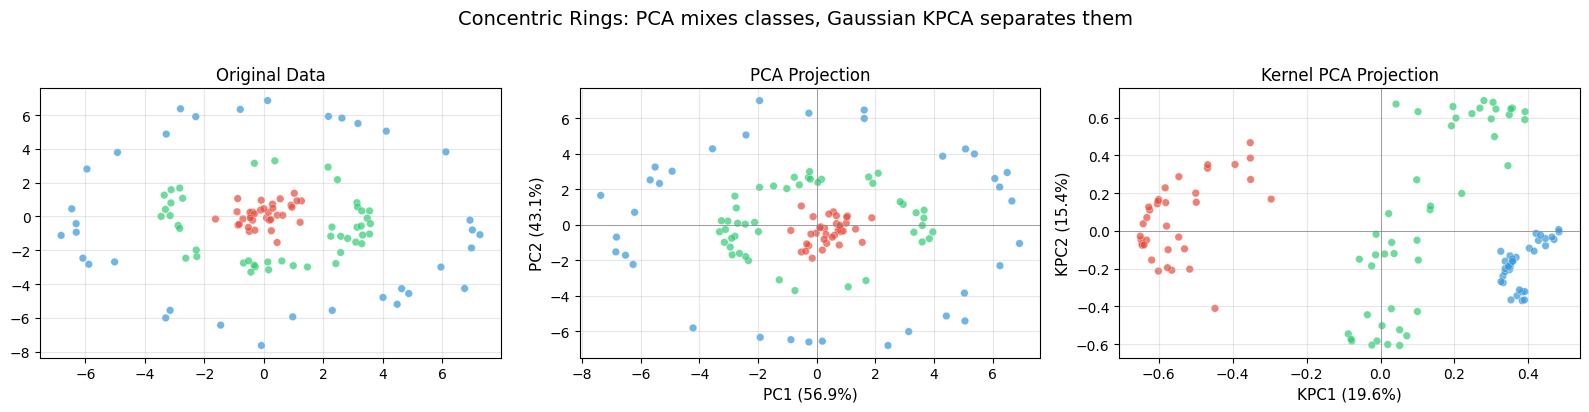

In [7]:
rng = np.random.default_rng(0)

n1, n2, n3 = 35, 45, 35
inner = rng.normal(0, 0.7, size=(n1, 2))

theta_mid = rng.uniform(0, 2*np.pi, n2)
r_mid = rng.normal(3.2, 0.35, n2)
middle = np.c_[r_mid * np.cos(theta_mid), r_mid * np.sin(theta_mid)]

theta_out = rng.uniform(0, 2*np.pi, n3)
r_out = rng.normal(6.6, 0.45, n3)
outer = np.c_[r_out * np.cos(theta_out), r_out * np.sin(theta_out)]

data_rings = np.vstack([inner, middle, outer])
labels = np.array([0]*n1 + [1]*n2 + [2]*n3)
ring_colors = np.array(['#e74c3c', '#2ecc71', '#3498db'])[labels]

print(f"Data shape: {data_rings.shape}")
print(f"Classes: {n1} inner, {n2} middle, {n3} outer")

# PCA
Z_pca, eigvecs, eigvals, pca_ratios = pca_project(data_rings)
print(f"\nPCA eigenvalues: {eigvals.round(4)}")
print(f"PCA explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")

# KPCA with Gaussian kernel
sigma = 2.0
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(data_rings, gaussian_kernel, sigma=sigma)
print(f"\nKPCA sigma: {sigma}")
print(f"KPCA top 5 eigenvalues: {kpca_eigvals[:5].round(4)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

plot_comparison(data_rings, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Concentric Rings: PCA mixes classes, Gaussian KPCA separates them",
                colors=ring_colors)


### Dataset 4: Two Moons

Two interleaving half-circles — another classic nonlinear separation problem. Again, PCA projects both classes onto the same range, while KPCA ($\sigma = 0.5$) pulls them apart.

Data shape: (200, 2)
Classes: 100 class 0, 100 class 1

PCA eigenvalues: [0.8384 0.1903]
PCA explained variance: 81.5%, 18.5%

KPCA sigma: 0.5
KPCA top 5 eigenvalues: [35.8077 28.2807 24.463  16.0536 15.1793]
KPCA explained variance: 22.8%, 18.0%


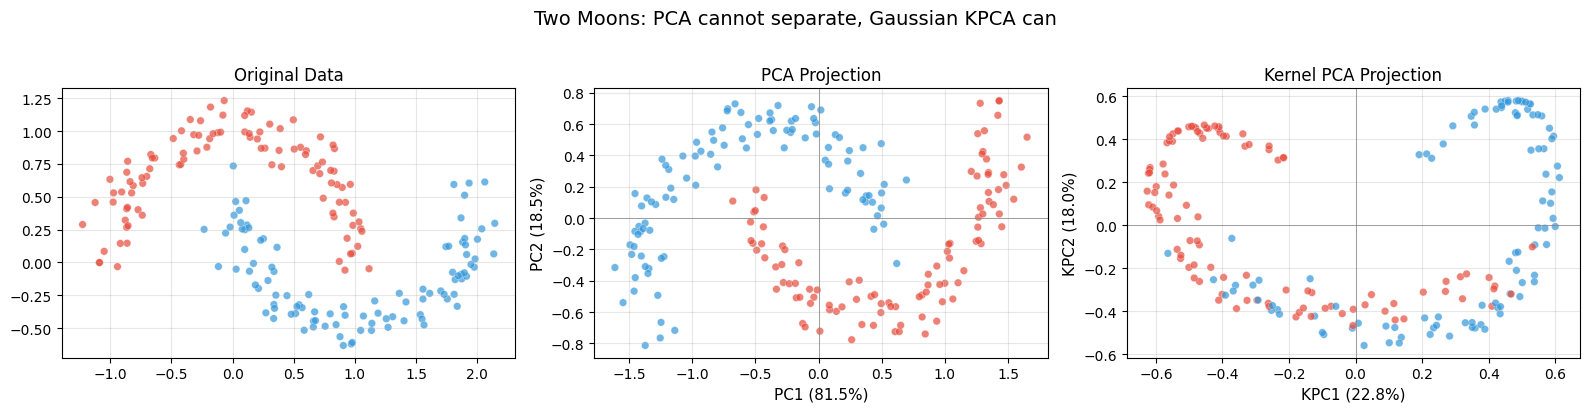

In [8]:
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
moon_colors = np.array(['#e74c3c', '#3498db'])[y_moons]

print(f"Data shape: {X_moons.shape}")
print(f"Classes: {np.sum(y_moons==0)} class 0, {np.sum(y_moons==1)} class 1")

# PCA
Z_pca, _, eigvals, pca_ratios = pca_project(X_moons)
print(f"\nPCA eigenvalues: {eigvals.round(4)}")
print(f"PCA explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")

# KPCA with Gaussian kernel
sigma = 0.5
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(X_moons, gaussian_kernel, sigma=sigma)
print(f"\nKPCA sigma: {sigma}")
print(f"KPCA top 5 eigenvalues: {kpca_eigvals[:5].round(4)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

plot_comparison(X_moons, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Two Moons: PCA cannot separate, Gaussian KPCA can",
                colors=moon_colors)


### Classification: Same k, Different Method

A fair comparison requires projecting to the **same number of dimensions** with both methods. For 2D input data, PCA has at most 2 components (k=1 or k=2). At k=2, PCA preserves all information and trivially achieves 100%. The interesting comparison is at **k=1**: both methods compress to one dimension, but PCA uses a linear projection while KPCA uses a nonlinear one.

We also show accuracy vs k for KPCA to reveal how quickly it reaches high accuracy compared to PCA.

At k=1 (same dimensionality, fair comparison):
  Rings:  PCA 65.7%  vs  KPCA 100.0%  (diff +34.3%)
  Moons:  PCA 80.0%  vs  KPCA 61.7%  (diff -18.3%)

At k=2 (PCA preserves all 2D info):
  Rings:  PCA 100.0%  vs  KPCA 100.0%
  Moons:  PCA 100.0%  vs  KPCA 93.3%


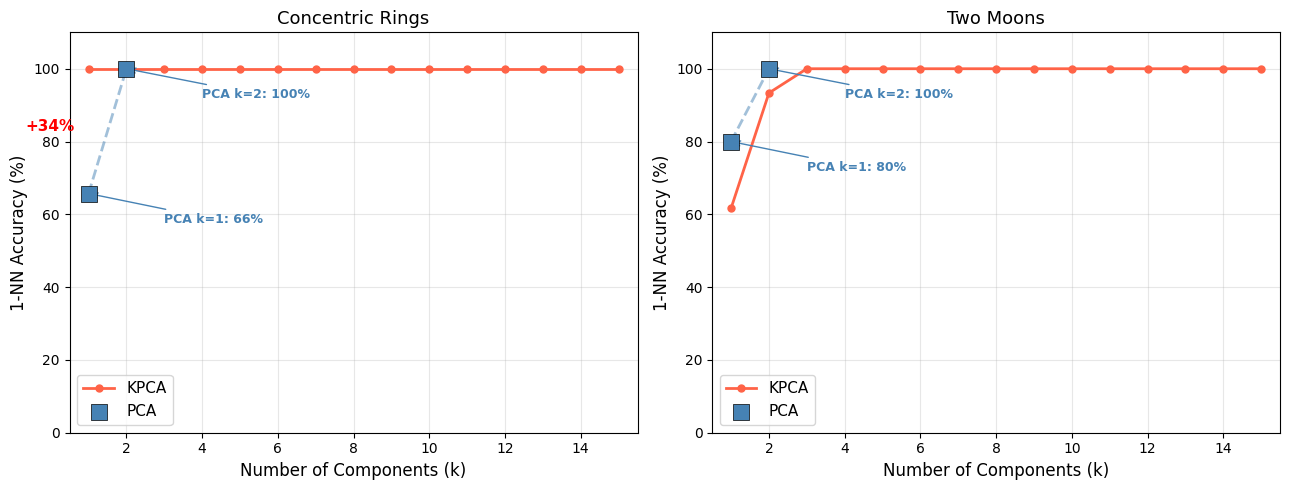


Key insight:
  At k=1, KPCA's single nonlinear component captures class structure
  that PCA's single linear component cannot.
  PCA catches up at k=2 (preserving all 2D info), but only because
  the original data is already 2D — on higher-dimensional data with
  nonlinear structure, this catch-up would not happen.


In [9]:
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist

def accuracy_vs_k(X, y, kernel_func, max_k=15, **kernel_params):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    N_tr = X_tr.shape[0]

    # PCA: k=1 and k=2
    Xc_tr = X_tr - X_tr.mean(axis=0); Xc_te = X_te - X_tr.mean(axis=0)
    S = np.cov(X_tr, rowvar=False)
    ev, evecs = np.linalg.eigh(S)
    idx = np.argsort(ev)[::-1]; evecs = evecs[:, idx]

    pca_accs = []
    for k in [1, 2]:
        W = evecs[:, :k]
        dists = cdist(Xc_te @ W, Xc_tr @ W)
        pca_accs.append(np.mean(y_tr[np.argmin(dists, axis=1)] == y_te) * 100)

    # KPCA: k=1 to max_k
    K_tr = kernel_func(X_tr, X_tr, **kernel_params)
    Kc_tr = center_kernel(K_tr)
    ev_k, evec_k = np.linalg.eigh(Kc_tr)
    idx_k = np.argsort(ev_k)[::-1]; ev_k = ev_k[idx_k]; evec_k = evec_k[:, idx_k]
    pos = ev_k > 1e-10; ev_k = ev_k[pos]; evec_k = evec_k[:, pos]
    alpha = evec_k / np.sqrt(ev_k)
    Z_tr = Kc_tr @ alpha

    one_N = np.ones((N_tr, N_tr)) / N_tr
    K_te = kernel_func(X_te, X_tr, **kernel_params)
    N_te = X_te.shape[0]; one_te = np.ones((N_te, N_tr)) / N_tr
    Kc_te = K_te - one_te @ K_tr - K_te @ one_N + one_te @ K_tr @ one_N
    Z_te = Kc_te @ alpha

    kpca_accs = []
    actual_max = min(max_k, Z_tr.shape[1])
    for k in range(1, actual_max + 1):
        dists = cdist(Z_te[:, :k], Z_tr[:, :k])
        kpca_accs.append(np.mean(y_tr[np.argmin(dists, axis=1)] == y_te) * 100)

    return pca_accs, kpca_accs

# Run
labels_rings = np.array([0]*35 + [1]*45 + [2]*35)
pca_r, kpca_r = accuracy_vs_k(data_rings, labels_rings, gaussian_kernel, sigma=2.0)
pca_m, kpca_m = accuracy_vs_k(X_moons, y_moons, gaussian_kernel, sigma=0.5)

# Print key comparison at k=1
print("At k=1 (same dimensionality, fair comparison):")
print(f"  Rings:  PCA {pca_r[0]:.1f}%  vs  KPCA {kpca_r[0]:.1f}%  (diff {kpca_r[0]-pca_r[0]:+.1f}%)")
print(f"  Moons:  PCA {pca_m[0]:.1f}%  vs  KPCA {kpca_m[0]:.1f}%  (diff {kpca_m[0]-pca_m[0]:+.1f}%)")
print(f"\nAt k=2 (PCA preserves all 2D info):")
print(f"  Rings:  PCA {pca_r[1]:.1f}%  vs  KPCA {kpca_r[1]:.1f}%")
print(f"  Moons:  PCA {pca_m[1]:.1f}%  vs  KPCA {kpca_m[1]:.1f}%")

# Plot: accuracy vs k
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (title, pca_a, kpca_a) in zip(axes, [
    ('Concentric Rings', pca_r, kpca_r),
    ('Two Moons', pca_m, kpca_m),
]):
    k_kpca = list(range(1, len(kpca_a)+1))

    # KPCA curve
    ax.plot(k_kpca, kpca_a, 'o-', color='tomato', markersize=5, linewidth=2, label='KPCA')

    # PCA: k=1 and k=2 as horizontal markers
    ax.scatter([1], [pca_a[0]], c='steelblue', s=120, zorder=5, marker='s', edgecolors='black', linewidths=0.5)
    ax.scatter([2], [pca_a[1]], c='steelblue', s=120, zorder=5, marker='s', edgecolors='black', linewidths=0.5)
    ax.plot([1, 2], pca_a, 's--', color='steelblue', markersize=0, linewidth=2, alpha=0.5)
    ax.annotate(f'PCA k=1: {pca_a[0]:.0f}%', xy=(1, pca_a[0]), xytext=(3, pca_a[0]-8),
                fontsize=9, color='steelblue', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1))
    ax.annotate(f'PCA k=2: {pca_a[1]:.0f}%', xy=(2, pca_a[1]), xytext=(4, pca_a[1]-8),
                fontsize=9, color='steelblue', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1))

    # Highlight k=1 comparison
    if kpca_a[0] > pca_a[0]:
        ax.annotate(f'+{kpca_a[0]-pca_a[0]:.0f}%', xy=(1, (kpca_a[0]+pca_a[0])/2),
                    fontsize=11, color='red', fontweight='bold', ha='right',
                    xytext=(-10, 0), textcoords='offset points')

    ax.set_xlabel('Number of Components (k)', fontsize=12)
    ax.set_ylabel('1-NN Accuracy (%)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(['KPCA', 'PCA'], fontsize=11)
    ax.set_ylim(0, 110)
    ax.set_xlim(0.5, len(kpca_a)+0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey insight:")
print(f"  At k=1, KPCA's single nonlinear component captures class structure")
print(f"  that PCA's single linear component cannot.")
print(f"  PCA catches up at k=2 (preserving all 2D info), but only because")
print(f"  the original data is already 2D — on higher-dimensional data with")
print(f"  nonlinear structure, this catch-up would not happen.")


### Summary

| Dataset | Structure | Kernel | PCA | KPCA |
|---------|-----------|--------|-----|------|
| Linear | $y = 0.5x + \text{noise}$ | Polynomial (d=3) | Captures well | No advantage |
| Nonlinear Boundary | $y \gtrless x^2$ | Polynomial (d=2) | Classes mixed | Classes separated |
| Concentric Rings | 3 circular clusters | Gaussian ($\sigma$=2.0) | 66% at k=1 | **100% at k=1** |
| Two Moons | 2 interleaving arcs | Gaussian ($\sigma$=0.5) | 80% at k=1 | 62% at k=1, **100% at k=3** |

**Key observations:**

1. KPCA components are ordered by **variance in kernel space**, not by classification accuracy. The first KPCA component may not be the most discriminative one (as seen in Two Moons).

2. PCA with k=2 on 2D data preserves all information trivially (100%). This is not a fair comparison — it only demonstrates that PCA with no dimensionality reduction loses nothing.

3. At the **same k=1** (fair comparison), KPCA wins on Rings (+34%) but loses on Moons (-18%). However, KPCA reaches 100% by k=3 on Moons, while PCA can only reach 100% by using all original dimensions.

4. The advantage of KPCA lies in its ability to extract nonlinear features from a richer (N-dimensional) space. On high-dimensional face images, this advantage vanishes because the Gaussian kernel approximates a linear one.